## This is the notebook to analyze the spectrum of the early optical light curve, red/blue? thermal/non-thermal?:

In [99]:
#Import packages
import numpy as np
import inspect
import scipy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import redback as rd
import bilby as bb
import astropy as ast
import pandas as pd
import warnings
import extinction as ex
from astropy.table import Table, Column
from astropy import units as u
from astropy import constants as const
import astropy.io.ascii as ascii
from pathlib import Path
import re
import inspect
warnings.filterwarnings('ignore')
from IPython.display import display, clear_output, Math


## Introducing the preprocessed data:

In [100]:
#From wavelength in Angstroms to frequencies in Hz:
def wavetof(wave):
    return(const.c.value/ (wave*1e-10))

CkeV = 1.602e-9   # erg/keV (Change of energy units from keV to erg)
hPlanck = 6.626e-27       # erg*s

#Defining because it's useful a function from E in keV to freq in Hz:
def Etonu(E):
    return E*CkeV/hPlanck

#Redshift of the source
z=0.401
ez=0.005
#Isotropic equivalent energy from the prompt by Sun et al:
Eiso=5.3*1e49*u.erg
Eiso_e=0.9*1e49*u.erg
Eiso_E=1.2*1e49*u.erg


#Introducing the real data:
#Function to convert from wavelength in Angstroms to frequencies in Hz:
def lambtofreq(lamb):
    return (const.c.value)/(lamb*1e-10)

def freqtolamb(freq):
    return ((const.c.value)/(freq))*1e10 #in Angstroms from freq in Hz

#Extracting and organizing the data in the following order:
#Radio-Optical-IRUV-X-rays:
RadioTXT='/data/egonzalezramos/EP240414a Edu processed data/All Radio Data EP240414a.txt'
Radio = Table.read(RadioTXT, format="ascii", comment="#")
OpticalTXT='/data/egonzalezramos/EP240414a Edu processed data/All Optical Data EP240414a.txt'
Optical = Table.read(OpticalTXT, format="ascii", comment="#")
IRUVTXT='/data/egonzalezramos/EP240414a Edu processed data/All IR UV Data EP240414a.txt'
IRUV = Table.read(IRUVTXT, format="ascii", comment="#")
XrayTXT='/data/egonzalezramos/EP240414a Edu processed data/Xray Data EP240414a.txt'
Xray = Table.read(XrayTXT, format="ascii", comment="#")

#Now putting all the data in the same units and in the same array:
RadioFreq=Radio['Frequency(GHz)']*1e9 #In Hertzs
RadioUB=np.where(Radio['Upper Limit Nature']=='Yes-3sigma')
RadioDat=np.where(Radio['Upper Limit Nature']=='No')
#3GHz
GHz3Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==3.0))[0]
#5.5GHz
GHz5Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==5.5))[0]
#9GHz
GHz9Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==9.0))[0]
#8GHz
GHz3UB = np.where((Radio['Upper Limit Nature']=='Yes-3sigma') & (Radio['Frequency(GHz)']==3.0))[0]
GHz8UB = np.where((Radio['Upper Limit Nature']=='Yes-3sigma') & (Radio['Frequency(GHz)']==8.0))[0]

#X-rays:
XRAYUB=np.where(Xray['Upper Limit Nature']=='Yes-1.645sigma')
XRAYDat=np.where(Xray['Upper Limit Nature']=='No')
XRAYDat=XRAYDat[0][1:] #Since the first point in Xrays corresponds to the prompt emission

#Optical:
gind=np.where(Optical['Filter']=='g')
rind=np.where(Optical['Filter']=='r')
iind=np.where(Optical['Filter']=='i')
zind=np.where(Optical['Filter']=='z')
gUBind=np.where(Optical['Filter']=='g-UB')
rUBind=np.where(Optical['Filter']=='r-UB')
iUBind=np.where(Optical['Filter']=='i-UB')
#Order of the Optical data: g r i z 

#Order of the IR UV: IR UV IR-UB
IRUVfreq=lambtofreq(IRUV['Effective-Wavelength(Angstroms)']) #In Hertzs

#X-rays, only for the afterglow points: The X-ray data is time ordered
CkeV = 1.602e-9   # erg/keV (Change of energy units from keV to erg)
hPlanck = 6.626e-27       # erg*s
stod=(1*u.s).to(u.d).value      #From seconds to days
XrayFreq=Xray['Frequency-of-evaluation-of-Fnu(KeV)'][1:]*CkeV/hPlanck #In Hertzs

In [101]:
#Now, let's divide the early optical light curve data in 3 regions: <0,2 days;
# 0,2 < x < 0,8; 0,8 < x < 1,5:
#g-band:
gTime=(Optical['Since-Trigger-Observed(s)'][gind].data*u.s).to(u.d)
gTimeDaysSortedIndices=np.argsort(gTime)
gTime=gTime[gTimeDaysSortedIndices]
gFlux=(Optical['Flux-Density(micro-Jankys)'][gind].data*u.uJy).to(u.mJy)
gFlux=gFlux[gTimeDaysSortedIndices]
gFlux_e=(Optical['Flux-Density_e(micro-Jankys)'][gind].data*u.uJy).to(u.mJy)
gFlux_e=gFlux_e[gTimeDaysSortedIndices]
gFlux_E=(Optical['Flux-Density_E(micro-Jankys)'][gind].data*u.uJy).to(u.mJy)
gFlux_E=gFlux_E[gTimeDaysSortedIndices]
gFreq=lambtofreq(Optical['Effective-Wavelength(Angstroms)'][gind].data)[0]

#r-band:
rTime=(Optical['Since-Trigger-Observed(s)'][rind].data*u.s).to(u.d)
rTimeDaysSortedIndices=np.argsort(rTime)
rTime=rTime[rTimeDaysSortedIndices]
rFlux=(Optical['Flux-Density(micro-Jankys)'][rind].data*u.uJy).to(u.mJy)
rFlux=rFlux[rTimeDaysSortedIndices]
rFlux_e=(Optical['Flux-Density_e(micro-Jankys)'][rind].data*u.uJy).to(u.mJy)
rFlux_e=rFlux_e[rTimeDaysSortedIndices]
rFlux_E=(Optical['Flux-Density_E(micro-Jankys)'][rind].data*u.uJy).to(u.mJy)
rFlux_E=rFlux_E[rTimeDaysSortedIndices]
rFreq=lambtofreq(Optical['Effective-Wavelength(Angstroms)'][rind].data)[0]

#i-band:
iTime=(Optical['Since-Trigger-Observed(s)'][iind].data*u.s).to(u.d)
iTimeDaysSortedIndices=np.argsort(iTime)
iTime=iTime[iTimeDaysSortedIndices]
iFlux=(Optical['Flux-Density(micro-Jankys)'][iind].data*u.uJy).to(u.mJy)
iFlux=iFlux[iTimeDaysSortedIndices]
iFlux_e=(Optical['Flux-Density_e(micro-Jankys)'][iind].data*u.uJy).to(u.mJy)
iFlux_e=iFlux_e[iTimeDaysSortedIndices]
iFlux_E=(Optical['Flux-Density_E(micro-Jankys)'][iind].data*u.uJy).to(u.mJy)
iFlux_E=iFlux_E[iTimeDaysSortedIndices]
iFreq=lambtofreq(Optical['Effective-Wavelength(Angstroms)'][iind].data)[0]

#z-band:
zTime=(Optical['Since-Trigger-Observed(s)'][zind].data*u.s).to(u.d)
zTimeDaysSortedIndices=np.argsort(zTime)
zTime=zTime[zTimeDaysSortedIndices]
zFlux=(Optical['Flux-Density(micro-Jankys)'][zind].data*u.uJy).to(u.mJy)
zFlux=zFlux[zTimeDaysSortedIndices]
zFlux_e=(Optical['Flux-Density_e(micro-Jankys)'][zind].data*u.uJy).to(u.mJy)
zFlux_e=zFlux_e[zTimeDaysSortedIndices]
zFlux_E=(Optical['Flux-Density_E(micro-Jankys)'][zind].data*u.uJy).to(u.mJy)
zFlux_E=zFlux_E[zTimeDaysSortedIndices]
zFreq=lambtofreq(Optical['Effective-Wavelength(Angstroms)'][zind].data)[0]

## For the first region <0.2d:

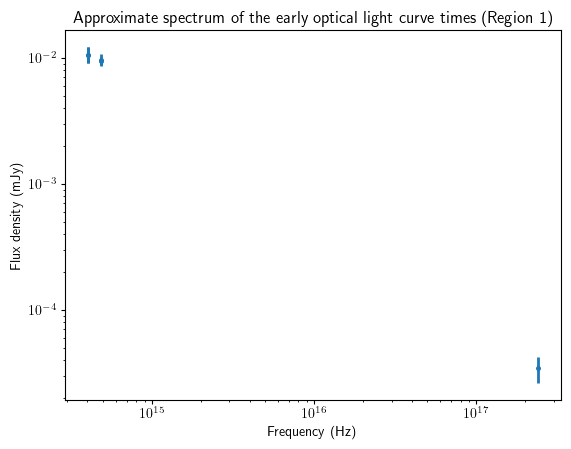

In [102]:
maskg1 = gTime.to_value(u.d) <= 0.2
maskr1 = rTime.to_value(u.d) <= 0.2
maski1 = iTime.to_value(u.d) <= 0.2
maskz1 = zTime.to_value(u.d) <= 0.2

#Cutting the arrays:
gFlux1=gFlux[maskg1]
gFlux_e1=gFlux_e[maskg1]
gFlux_E1=gFlux_E[maskg1]
gFreq1=gFreq*np.ones(len(gFlux1))

rFlux1=rFlux[maskr1]
rFlux_e1=rFlux_e[maskr1]
rFlux_E1=rFlux_E[maskr1]
rFreq1=rFreq*np.ones(len(rFlux1))

iFlux1=iFlux[maski1]
iFlux_e1=iFlux_e[maski1]
iFlux_E1=iFlux_E[maski1]
iFreq1=iFreq*np.ones(len(iFlux1))

zFlux1=zFlux[maskz1]
zFlux_e1=zFlux_e[maskz1]
zFlux_E1=zFlux_E[maskz1]
zFreq1=zFreq*np.ones(len(zFlux1))

# #Since I have two r points and two i points in this region, I'm going to consider the weighted mean
# #for fitting propagating the errors by quadrature:
# weightsr= 1 / ((rFlux_e1 + rFlux_E1)/2)**2  # approximate symmetric weights
# flux1_meanr = np.sum(rFlux1 * weightsr) / np.sum(weightsr)
# flux1_meanr_e = np.sqrt(np.sum(rFlux_e1**2)) / len(rFlux_e1)
# flux1_meanr_E = np.sqrt(np.sum(rFlux_E1**2)) / len(rFlux_E1)


# weightsi= 1 / ((iFlux_e1 + iFlux_E1)/2)**2  # approximate symmetric weights
# flux1_meani = np.sum(iFlux1 * weightsi) / np.sum(weightsi)
# flux1_meani_e = np.sqrt(np.sum(iFlux_e1**2)) / len(iFlux_e1)
# flux1_meani_E = np.sqrt(np.sum(iFlux_E1**2)) / len(iFlux_E1)


#The first X-ray point also belong to this region so, in this order: X-ray, g, r, i ,z
Flux1=np.append((Xray['Flux-Density(micro-Jankys)'][3].data*u.uJy).to(u.mJy),gFlux1)
Flux1=np.append(Flux1,rFlux1)
Flux1=np.append(Flux1,iFlux1)
Flux1=np.append(Flux1,zFlux1)

Flux1_e=np.append((Xray['Flux-Density_e(micro-Jankys)'][3].data*u.uJy).to(u.mJy),gFlux_e1)
Flux1_e=np.append(Flux1_e,rFlux_e1)
Flux1_e=np.append(Flux1_e,iFlux_e1)
Flux1_e=np.append(Flux1_e,zFlux_e1)

Flux1_E=np.append((Xray['Flux-Density_E(micro-Jankys)'][3].data*u.uJy).to(u.mJy),gFlux_E1)
Flux1_E=np.append(Flux1_E,rFlux_E1)
Flux1_E=np.append(Flux1_E,iFlux_E1)
Flux1_E=np.append(Flux1_E,zFlux_E1)

Freq1=np.append(XrayFreq.data[1],gFreq1)
Freq1=np.append(Freq1,rFreq1)
Freq1=np.append(Freq1,iFreq1)
Freq1=np.append(Freq1,zFreq1)

#And plotting the result:
plt.figure()
plt.errorbar(x=Freq1, y=Flux1, yerr=np.vstack([Flux1_e,Flux1_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 1)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

## For the second region 0.2d<x<0.8d:

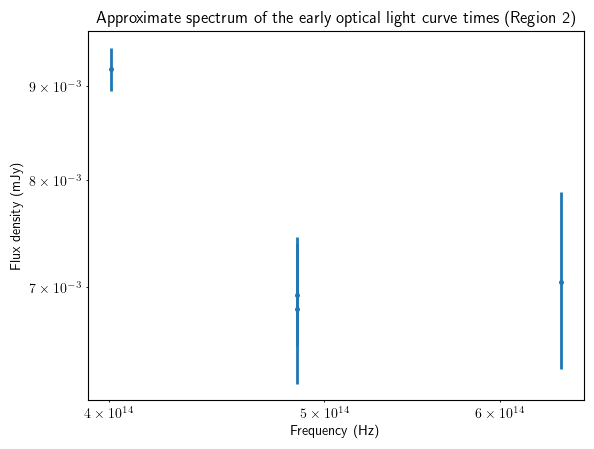

In [103]:
maskg2 = (gTime.to_value(u.d) > 0.2) & (gTime.to_value(u.d) <= 0.8)
maskr2 = (rTime.to_value(u.d) > 0.2) & (rTime.to_value(u.d) <= 0.8)
maski2 = (iTime.to_value(u.d) > 0.2) & (iTime.to_value(u.d) <= 0.8)
maskz2 = (zTime.to_value(u.d) > 0.2) & (zTime.to_value(u.d) <= 0.8)

#Cutting the arrays:
gFlux2=gFlux[maskg2]
gFlux_e2=gFlux_e[maskg2]
gFlux_E2=gFlux_E[maskg2]
gFreq2=gFreq*np.ones(len(gFlux2))

rFlux2=rFlux[maskr2]
rFlux_e2=rFlux_e[maskr2]
rFlux_E2=rFlux_E[maskr2]
rFreq2=rFreq*np.ones(len(rFlux2))

iFlux2=iFlux[maski2]
iFlux_e2=iFlux_e[maski2]
iFlux_E2=iFlux_E[maski2]
iFreq2=iFreq*np.ones(len(iFlux2))

zFlux2=zFlux[maskz2]
zFlux_e2=zFlux_e[maskz2]
zFlux_E2=zFlux_E[maskz2]
zFreq2=zFreq*np.ones(len(zFlux2))


#In this order: g, r, i ,z
Flux2=np.append(gFlux2,rFlux2)
Flux2=np.append(Flux2,iFlux2)
Flux2=np.append(Flux2,zFlux2)


Flux2_e=np.append(gFlux_e2,rFlux_e2)
Flux2_e=np.append(Flux2_e,iFlux_e2)
Flux2_e=np.append(Flux2_e,zFlux_e2)


Flux2_E=np.append(gFlux_E2,rFlux_E2)
Flux2_E=np.append(Flux2_E,iFlux_E2)
Flux2_E=np.append(Flux2_E,zFlux_E2)

Freq2=np.append(gFreq2,rFreq2)
Freq2=np.append(Freq2,iFreq2)
Freq2=np.append(Freq2,zFreq2)


#And plotting the result:
plt.figure()
plt.errorbar(x=Freq2, y=Flux2, yerr=np.vstack([Flux2_e,Flux2_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 2)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

## For the third region 0.8d<x<1.5d:

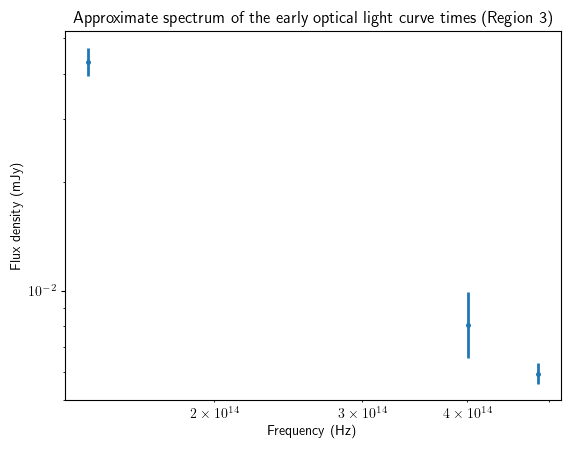

In [104]:
maskg3 = (gTime.to_value(u.d) > 0.8) & (gTime.to_value(u.d) <= 1.5)
maskr3 = (rTime.to_value(u.d) > 0.8) & (rTime.to_value(u.d) <= 1.5)
maski3 = (iTime.to_value(u.d) > 0.8) & (iTime.to_value(u.d) <= 1.5)
maskz3 = (zTime.to_value(u.d) > 0.8) & (zTime.to_value(u.d) <= 1.5)

#Cutting the arrays:
gFlux3=gFlux[maskg3]
gFlux_e3=gFlux_e[maskg3]
gFlux_E3=gFlux_E[maskg3]
gFreq3=gFreq*np.ones(len(gFlux3))

rFlux3=rFlux[maskr3]
rFlux_e3=rFlux_e[maskr3]
rFlux_E3=rFlux_E[maskr3]
rFreq3=rFreq*np.ones(len(rFlux3))

iFlux3=iFlux[maski3]
iFlux_e3=iFlux_e[maski3]
iFlux_E3=iFlux_E[maski3]
iFreq3=iFreq*np.ones(len(iFlux3))

zFlux3=zFlux[maskz3]
zFlux_e3=zFlux_e[maskz3]
zFlux_E3=zFlux_E[maskz3]
zFreq3=zFreq*np.ones(len(zFlux3))

#For the IRUV point:
IRtime=(IRUV['Since-Trigger-Observed (s)'].data*u.s).to(u.d)
IRfreq=lambtofreq(IRUV['Effective-Wavelength(Angstroms)'].data)
IRFlux=(IRUV['Flux-Density(micro-Jankys)'].data*u.uJy).to(u.mJy)
IRFlux_e=(IRUV['Flux-Density_e(micro-Jankys)'].data*u.uJy).to(u.mJy)
IRFlux_E=(IRUV['Flux-Density_E(micro-Jankys)'].data*u.uJy).to(u.mJy)

#Cutting the points:
IRmask1=(IRtime.to_value(u.d) > 0.8) & (IRtime.to_value(u.d) <= 1.5)
IRfreq1=IRfreq[IRmask1]
IRFlux1=IRFlux[IRmask1]
IRFlux_e1=IRFlux_e[IRmask1]
IRFlux_E1=IRFlux_E[IRmask1]

#In this order: IR, g, r, i ,z
Flux3=np.append(IRFlux1,gFlux3)
Flux3=np.append(Flux3,rFlux3)
Flux3=np.append(Flux3,iFlux3)
Flux3=np.append(Flux3,zFlux3)

Flux3_e=np.append(IRFlux_e1,gFlux_e3)
Flux3_e=np.append(Flux3_e,rFlux_e3)
Flux3_e=np.append(Flux3_e,iFlux_e3)
Flux3_e=np.append(Flux3_e,zFlux_e3)

Flux3_E=np.append(IRFlux_E1,gFlux_E3)
Flux3_E=np.append(Flux3_E,rFlux_E3)
Flux3_E=np.append(Flux3_E,iFlux_E3)
Flux3_E=np.append(Flux3_E,zFlux_E3)

Freq3=np.append(IRfreq1,gFreq3)
Freq3=np.append(Freq3,rFreq3)
Freq3=np.append(Freq3,iFreq3)
Freq3=np.append(Freq3,zFreq3)

#And plotting the result:
plt.figure()
plt.errorbar(x=Freq3, y=Flux3, yerr=np.vstack([Flux3_e,Flux3_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 3)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

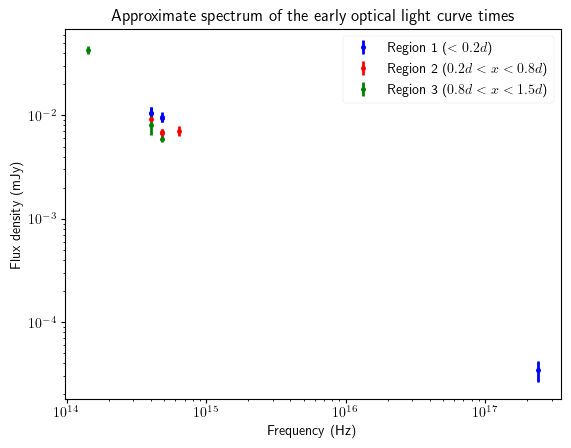

In [105]:
#All the data in the same plot:
#And plotting the result:
plt.figure()
plt.errorbar(x=Freq1, y=Flux1, yerr=np.vstack([Flux1_e,Flux1_E]),  fmt='o', capsize=5, elinewidth=2, color= 'blue', label='Region 1 ($<0.2d$)')
plt.errorbar(x=Freq2, y=Flux2, yerr=np.vstack([Flux2_e,Flux2_E]),  fmt='o', capsize=5, elinewidth=2, color= 'red', label='Region 2 ($0.2d<x<0.8d$)')
plt.errorbar(x=Freq3, y=Flux3, yerr=np.vstack([Flux3_e,Flux3_E]),  fmt='o', capsize=5, elinewidth=2, color= 'green', label='Region 3 ($0.8d<x<1.5d$)')
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.show()

# Now fitting these points to PLs and BB.

In [106]:
#Power Law that we will use to fit the data:
def logPLSED(freq, a, beta):
    return a + beta* np.log10(freq)


#And for the blackbody fitting, we will use:
#For the luminosity distance in cm
from astropy.cosmology import Planck18 as cosmo

def logBBSED(freq, temperature):
    freq = freq * (1 + z)  # source frame
    dl=cosmo.luminosity_distance(z).to(u.cm)
    r_photosphere=1e15
    Fnu = rd.sed.blackbody_to_flux_density(
        temperature=temperature,
        r_photosphere=r_photosphere,
        dl=dl.value,
        frequency=freq
    )
    Fnu=Fnu.to(u.mJy)
    return np.log10(Fnu.value)

#And for simple fitting:
from scipy.optimize import curve_fit

## For the first region:

In [107]:
# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:


LogFlux1Fit=np.log10(Flux1.value)
LogFlux1Fit_e=Flux1_e.value / (Flux1.value * np.log(10))
LogFlux1Fit_E=Flux1_E.value / (Flux1.value * np.log(10))

# So, fitting:
#For the power law:
poptPL, pcovPL = curve_fit(logPLSED, Freq1, LogFlux1Fit, sigma=np.maximum(LogFlux1Fit_e,LogFlux1Fit_E))

a_fit, beta_fit = poptPL
perrPL = np.sqrt(np.diag(pcovPL))
print('Best fitting a parameter: ', a_fit, 'pm', perrPL[0]) 
print('Best fitting beta parameter: ', beta_fit, 'pm', perrPL[1])


# model residuals
y_modelPL = logPLSED(Freq1, a_fit, beta_fit)
residualsPL =  LogFlux1Fit - y_modelPL

# using symmetric sigma (maximum of lower/upper)
sigma_symPL = np.maximum(LogFlux1Fit_e, LogFlux1Fit_E)

chi2PL = np.sum((residualsPL / sigma_symPL)**2)
dofPL = len(LogFlux1Fit) - len(poptPL)  # degrees of freedom: data points - parameters
chi2_redPL = chi2PL / dofPL

print("chi2 =", chi2PL)
print("reduced chi2 =", chi2_redPL)





#For the Blackbody fitting:
poptBB, pcovBB = curve_fit(logBBSED, Freq1, LogFlux1Fit, sigma=np.maximum(LogFlux1Fit_e,LogFlux1Fit_E))

T_fit = poptBB
perrBB = np.sqrt(np.diag(pcovBB))
print('Best fitting Teff parameter: ', T_fit, 'pm', perrBB[0]) 
#print('Best fitting Rphoto parameter: ', R_fit, 'pm', perrBB[1])


# model residuals
y_modelBB = logBBSED(Freq1, T_fit)
residualsBB =  LogFlux1Fit - y_modelBB

# using symmetric sigma (maximum of lower/upper)
sigma_symBB = np.maximum(LogFlux1Fit_e, LogFlux1Fit_E)

chi2BB = np.sum((residualsBB / sigma_symBB)**2)
dofBB = len(LogFlux1Fit) - len(poptBB)  # degrees of freedom: data points - parameters
chi2_redBB = chi2BB / dofBB

print("chi2 =", chi2BB)
print("reduced chi2 =", chi2_redBB)

Best fitting a parameter:  11.20619366116276 pm 0.18820006561089908
Best fitting beta parameter:  -0.9012660962011682 pm 0.01270138870655544
chi2 = 0.322682766572472
reduced chi2 = 0.10756092219082401
Best fitting Teff parameter:  [1.] pm inf
chi2 = inf
reduced chi2 = inf


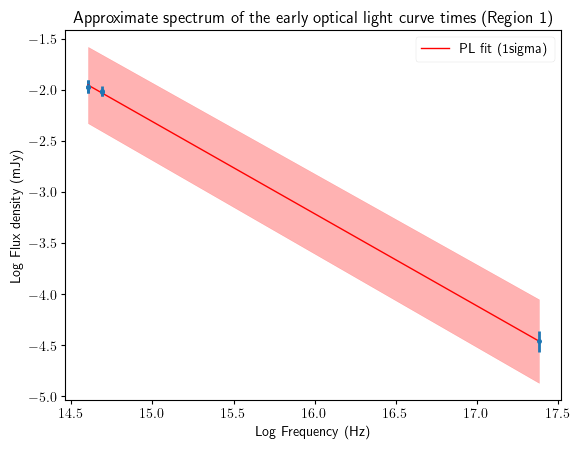

In [108]:
#And plotting the result:
xplot=np.linspace(np.log10(Freq1).min(), np.log10(Freq1).max(), 200)
yplot=logPLSED(10**(xplot), *poptPL)
onesigmalow=logPLSED(10**(xplot), *(poptPL-perrPL))
onesigmaupper=logPLSED(10**(xplot), *(poptPL+perrPL))

plt.figure()
plt.errorbar(x=np.log10(Freq1), y=LogFlux1Fit, yerr=np.vstack([LogFlux1Fit_e, LogFlux1Fit_E]),  fmt='o', capsize=5, elinewidth=2)
plt.plot(xplot, yplot, color="red", label="PL fit (1sigma)")
plt.fill_between(xplot, onesigmalow, onesigmaupper, alpha= 0.3,color="red")
plt.title('Approximate spectrum of the early optical light curve times (Region 1)')
plt.ylabel('Log Flux density (mJy)')
plt.xlabel('Log Frequency (Hz)')
plt.legend()
plt.show()

## For the second region:

In [109]:
#For the luminosity distance in cm
from astropy.cosmology import Planck18 as cosmo

# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:


LogFlux2Fit=np.log10(Flux2.value)
LogFlux2Fit_e=Flux2_e.value / (Flux2.value * np.log(10))
LogFlux2Fit_E=Flux2_E.value / (Flux2.value * np.log(10))

# So, fitting:
#For the power law:
popt2, pcov2 = curve_fit(logPLSED, Freq2, LogFlux2Fit, sigma=np.maximum(LogFlux2Fit_e,LogFlux2Fit_E))

a_fit2, beta_fit2 = popt2
perr2 = np.sqrt(np.diag(pcov2))
print('Best fitting a parameter: ', a_fit2, 'pm', perr2[0]) 
print('Best fitting beta parameter: ', beta_fit2, 'pm', perr2[1])


# model residuals
y_model2 = logPLSED(Freq2, a_fit2, beta_fit2)
residuals2 =  LogFlux2Fit - y_model2

# using symmetric sigma (maximum of lower/upper)
sigma_sym2 = np.maximum(LogFlux2Fit_e, LogFlux2Fit_E)

chi22 = np.sum((residuals2 / sigma_sym2)**2)
dof2 = len(LogFlux2Fit) - len(popt2)  # degrees of freedom: data points - parameters
chi2_red2 = chi22 / dof2

print("chi2 =", chi22)
print("reduced chi2 =", chi2_red2)


#For the Blackbody fitting:
poptBB2, pcovBB2 = curve_fit(logBBSED, Freq2, LogFlux2Fit, sigma=np.maximum(LogFlux2Fit_e,LogFlux2Fit_E))

T_fit2 = poptBB2
perrBB2 = np.sqrt(np.diag(pcovBB2))
print('Best fitting Teff parameter: ', T_fit2, 'pm', perrBB2[0]) 
#print('Best fitting Rphoto parameter: ', R_fit2, 'pm', perrBB2[1])


# model residuals
y_modelBB2 = logBBSED(Freq2, T_fit2)
residualsBB2 =  LogFlux2Fit - y_modelBB2

# using symmetric sigma (maximum of lower/upper)
sigma_symBB2 = np.maximum(LogFlux2Fit_e, LogFlux2Fit_E)

chi2BB2 = np.sum((residualsBB2 / sigma_symBB2)**2)
dofBB2 = len(LogFlux2Fit) - len(poptBB2)  # degrees of freedom: data points - parameters
chi2_redBB2 = chi2BB2 / dofBB2

print("chi2 =", chi2BB2)
print("reduced chi2 =", chi2_redBB2)

Best fitting a parameter:  11.598761312597036 pm 5.18736765539339
Best fitting beta parameter:  -0.9341717538106048 pm 0.3546203191870965
chi2 = 5.607693045519233
reduced chi2 = 2.8038465227596165
Best fitting Teff parameter:  [1.] pm inf
chi2 = inf
reduced chi2 = inf


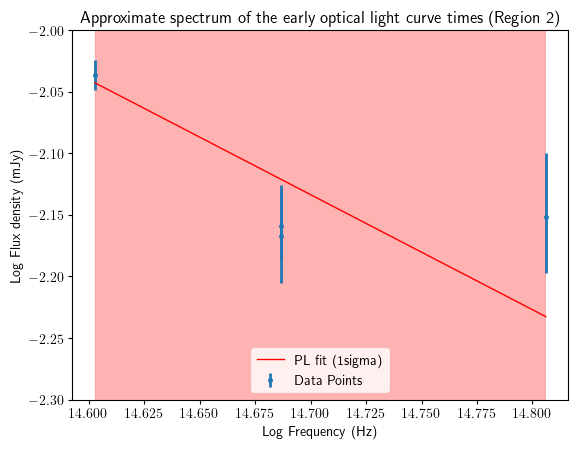

In [110]:
#And plotting the result:
xplot2=np.linspace(np.log10(Freq2).min(), np.log10(Freq2).max(), 200)
yplot2=logPLSED(10**(xplot2), *popt2)
onesigmalow2=logPLSED(10**(xplot2), *(popt2-perr2))
onesigmaupper2=logPLSED(10**(xplot2), *(popt2+perr2))

plt.figure()
plt.errorbar(x=np.log10(Freq2), y=LogFlux2Fit, yerr=np.vstack([LogFlux2Fit_e, LogFlux2Fit_E]),  fmt='o', capsize=5, elinewidth=2, label= 'Data Points')
plt.plot(xplot2, yplot2, color="red", label="PL fit (1sigma)")
plt.fill_between(xplot2, onesigmalow2, onesigmaupper2, alpha= 0.3,color="red")
plt.title('Approximate spectrum of the early optical light curve times (Region 2)')
plt.ylabel('Log Flux density (mJy)')
plt.xlabel('Log Frequency (Hz)')
plt.ylim(-2.3,-2)
plt.legend()
plt.show()

## For the third region:

In [111]:
#For the luminosity distance in cm
from astropy.cosmology import Planck18 as cosmo

# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:


LogFlux3Fit=np.log10(Flux3.value)
LogFlux3Fit_e=Flux3_e.value / (Flux3.value * np.log(10))
LogFlux3Fit_E=Flux3_E.value / (Flux3.value * np.log(10))

# So, fitting:
#For the power law:
popt3, pcov3 = curve_fit(logPLSED, Freq3, LogFlux3Fit, sigma=np.maximum(LogFlux3Fit_e,LogFlux3Fit_E))

a_fit3, beta_fit3 = popt3
perr3 = np.sqrt(np.diag(pcov3))
print('Best fitting a parameter: ', a_fit3, 'pm', perr3[0]) 
print('Best fitting beta parameter: ', beta_fit3, 'pm', perr3[1])


# model residuals
y_model3 = logPLSED(Freq3, a_fit3, beta_fit3)
residuals3 =  LogFlux3Fit - y_model3

# using symmetric sigma (maximum of lower/upper)
sigma_sym3 = np.maximum(LogFlux3Fit_e, LogFlux3Fit_E)

chi23 = np.sum((residuals3 / sigma_sym3)**2)
dof3 = len(LogFlux3Fit) - len(popt3)  # degrees of freedom: data points - parameters
chi2_red3 = chi23 / dof3

print("chi2 =", chi23)
print("reduced chi2 =", chi2_red3)




#For the Blackbody fitting:
poptBB3, pcovBB3 = curve_fit(logBBSED, Freq3, LogFlux3Fit, sigma=np.maximum(LogFlux3Fit_e,LogFlux3Fit_E))

T_fit3 = poptBB3
perrBB3 = np.sqrt(np.diag(pcovBB3))
print('Best fitting Teff parameter: ', T_fit3, 'pm', perrBB3[0]) 
#print('Best fitting Rphoto parameter: ', R_fit3, 'pm', perrBB3[1])


# model residuals
y_modelBB3 = logBBSED(Freq3, T_fit3)
residualsBB3 =  LogFlux3Fit - y_modelBB3

# using symmetric sigma (maximum of lower/upper)
sigma_symBB3 = np.maximum(LogFlux3Fit_e, LogFlux3Fit_E)

chi2BB3 = np.sum((residualsBB3 / sigma_symBB3)**2)
dofBB3 = len(LogFlux3Fit) - len(poptBB3)  # degrees of freedom: data points - parameters
chi2_redBB3 = chi2BB3 / dofBB3

print("chi2 =", chi2BB3)
print("reduced chi2 =", chi2_redBB3)

Best fitting a parameter:  21.316535335945126 pm 0.015562005569056563
Best fitting beta parameter:  -1.6030337076317709 pm 0.0010716871266398407
chi2 = 0.00013003412272884966
reduced chi2 = 0.00013003412272884966
Best fitting Teff parameter:  [1.] pm inf
chi2 = inf
reduced chi2 = inf


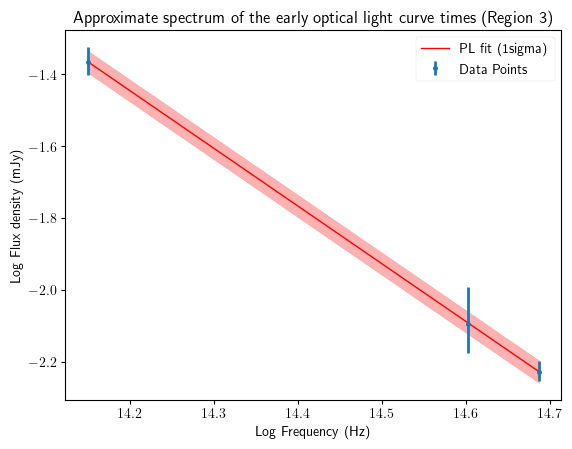

In [112]:
#And plotting the result:
xplot3=np.linspace(np.log10(Freq3).min(), np.log10(Freq3).max(), 200)
yplot3=logPLSED(10**(xplot3), *popt3)
onesigmalow3=logPLSED(10**(xplot3), *(popt3-perr3))
onesigmaupper3=logPLSED(10**(xplot3), *(popt3+perr3))

plt.figure()
plt.errorbar(x=np.log10(Freq3), y=LogFlux3Fit, yerr=np.vstack([LogFlux3Fit_e, LogFlux3Fit_E]),  fmt='o', capsize=5, elinewidth=2, label= 'Data Points')
plt.plot(xplot3, yplot3, color="red", label="PL fit (1sigma)")
plt.fill_between(xplot3, onesigmalow3, onesigmaupper3, alpha= 0.3,color="red")
plt.title('Approximate spectrum of the early optical light curve times (Region 3)')
plt.ylabel('Log Flux density (mJy)')
plt.xlabel('Log Frequency (Hz)')
plt.legend()
plt.show()

## All together:

In [113]:
print('REGION 1 (<0.2d):')
print('Best fitting a parameter: ', a_fit, 'pm', perrPL[0]) 
print('Best fitting beta parameter: ', beta_fit, 'pm', perrPL[1])
print("chi2 =", chi2PL)
print("reduced chi2 =", chi2_redPL)
print('Best fitting Teff parameter: ', T_fit, 'pm', perrBB[0]) 
#print('Best fitting Rphoto parameter: ', R_fit, 'pm', perrBB[1])
print("chi2 =", chi2BB)
print("reduced chi2 =", chi2_redBB)

print('REGION 2 (0.2d<x<0.8d):')
print('Best fitting a parameter: ', a_fit2, 'pm', perr2[0]) 
print('Best fitting beta parameter: ', beta_fit2, 'pm', perr2[1])
print("chi2 =", chi22)
print("reduced chi2 =", chi2_red2)
print('Best fitting Teff parameter: ', T_fit2, 'pm', perrBB2[0]) 
#print('Best fitting Rphoto parameter: ', R_fit2, 'pm', perrBB2[1])
print("chi2 =", chi2BB2)
print("reduced chi2 =", chi2_redBB2)

print('REGION 3 (0.8d<x<1.5d):')
print('Best fitting a parameter: ', a_fit3, 'pm', perr3[0]) 
print('Best fitting beta parameter: ', beta_fit3, 'pm', perr3[1])
print("chi2 =", chi23)
print("reduced chi2 =", chi2_red3)
print('Best fitting Teff parameter: ', T_fit3, 'pm', perrBB3[0]) 
#print('Best fitting Rphoto parameter: ', R_fit3, 'pm', perrBB3[1])
print("chi2 =", chi2BB3)
print("reduced chi2 =", chi2_redBB3)

REGION 1 (<0.2d):
Best fitting a parameter:  11.20619366116276 pm 0.18820006561089908
Best fitting beta parameter:  -0.9012660962011682 pm 0.01270138870655544
chi2 = 0.322682766572472
reduced chi2 = 0.10756092219082401
Best fitting Teff parameter:  [1.] pm inf
chi2 = inf
reduced chi2 = inf
REGION 2 (0.2d<x<0.8d):
Best fitting a parameter:  11.598761312597036 pm 5.18736765539339
Best fitting beta parameter:  -0.9341717538106048 pm 0.3546203191870965
chi2 = 5.607693045519233
reduced chi2 = 2.8038465227596165
Best fitting Teff parameter:  [1.] pm inf
chi2 = inf
reduced chi2 = inf
REGION 3 (0.8d<x<1.5d):
Best fitting a parameter:  21.316535335945126 pm 0.015562005569056563
Best fitting beta parameter:  -1.6030337076317709 pm 0.0010716871266398407
chi2 = 0.00013003412272884966
reduced chi2 = 0.00013003412272884966
Best fitting Teff parameter:  [1.] pm inf
chi2 = inf
reduced chi2 = inf


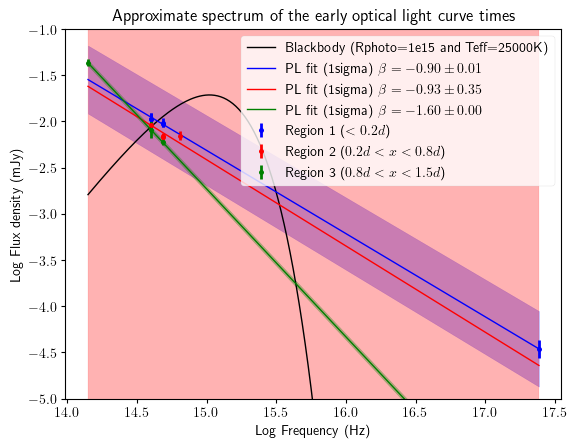

In [114]:
#Plotting everything:
Freqplot=np.append(Freq1,Freq2)
Freqplot=np.append(Freqplot, Freq3)

xplot=np.linspace(np.log10(Freqplot.min()), np.log10(Freqplot.max()), 300)
yplot1=logPLSED(10**(xplot), *poptPL)
onesigmalow1=logPLSED(10**(xplot), *(poptPL-perrPL))
onesigmaupper1=logPLSED(10**(xplot), *(poptPL+perrPL))

yplot2=logPLSED(10**(xplot), *popt2)
onesigmalow2=logPLSED(10**(xplot), *(popt2-perr2))
onesigmaupper2=logPLSED(10**(xplot), *(popt2+perr2))

yplot3=logPLSED(10**(xplot), *popt3)
onesigmalow3=logPLSED(10**(xplot), *(popt3-perr3))
onesigmaupper3=logPLSED(10**(xplot), *(popt3+perr3))

plt.figure()
plt.errorbar(x=np.log10(Freq1), y=LogFlux1Fit, yerr=np.vstack([LogFlux1Fit_e,LogFlux1Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'blue', label='Region 1 ($<0.2d$)')
plt.errorbar(x=np.log10(Freq2), y=LogFlux2Fit, yerr=np.vstack([LogFlux2Fit_e,LogFlux2Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'red', label='Region 2 ($0.2d<x<0.8d$)')
plt.errorbar(x=np.log10(Freq3), y=LogFlux3Fit, yerr=np.vstack([LogFlux3Fit_e,LogFlux3Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'green', label='Region 3 ($0.8d<x<1.5d$)')
plt.plot(xplot, logBBSED(10**xplot, 25000), color='k', label= 'Blackbody (Rphoto=1e15 and Teff=25000K)' )
plt.plot(xplot, yplot1, color="blue", label=rf"PL fit (1sigma) $\beta={beta_fit:.2f} \pm {perrPL[1]:.2f}$")
plt.fill_between(xplot, onesigmalow1, onesigmaupper1, alpha= 0.3,color="blue")
plt.plot(xplot, yplot2, color="red", label=rf"PL fit (1sigma) $\beta={beta_fit2:.2f} \pm {perr2[1]:.2f}$")
plt.fill_between(xplot, onesigmalow2, onesigmaupper2, alpha= 0.3,color="red")
plt.plot(xplot, yplot3, color="green", label=rf"PL fit (1sigma) $\beta={beta_fit3:.2f} \pm {perr3[1]:.2f}$")
plt.fill_between(xplot, onesigmalow3, onesigmaupper3, alpha= 0.3,color="green")
plt.title('Approximate spectrum of the early optical light curve times')
plt.ylabel('Log Flux density (mJy)')
plt.xlabel('Log Frequency (Hz)')
plt.ylim(-5, -1)
plt.legend()
plt.show()

# Now for regions in the peak:

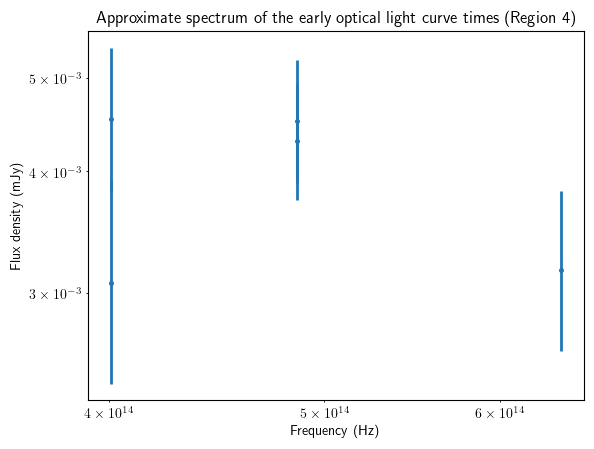

In [115]:
# From 1.5 days to 1.75:
maskg4 = (gTime.to_value(u.d) >= 1.5) & (gTime.to_value(u.d) <= 1.75)
maskr4 = (rTime.to_value(u.d) >= 1.5) & (rTime.to_value(u.d) <= 1.75)
maski4 = (iTime.to_value(u.d) >= 1.5) & (iTime.to_value(u.d) <= 1.75)
maskz4 = (zTime.to_value(u.d) >= 1.5) & (zTime.to_value(u.d) <= 1.75)

#Cutting the arrays:
gFlux4=gFlux[maskg4]
gFlux_e4=gFlux_e[maskg4]
gFlux_E4=gFlux_E[maskg4]
gFreq4=gFreq*np.ones(len(gFlux4))

rFlux4=rFlux[maskr4]
rFlux_e4=rFlux_e[maskr4]
rFlux_E4=rFlux_E[maskr4]
rFreq4=rFreq*np.ones(len(rFlux4))

iFlux4=iFlux[maski4]
iFlux_e4=iFlux_e[maski4]
iFlux_E4=iFlux_E[maski4]
iFreq4=iFreq*np.ones(len(iFlux4))

zFlux4=zFlux[maskz4]
zFlux_e4=zFlux_e[maskz4]
zFlux_E4=zFlux_E[maskz4]
zFreq4=zFreq*np.ones(len(zFlux4))



#In this order:  g, r, i ,z
Flux4=np.append(gFlux4,rFlux4)
Flux4=np.append(Flux4,iFlux4)
Flux4=np.append(Flux4,zFlux4)

Flux4_e=np.append(gFlux_e4,rFlux_e4)
Flux4_e=np.append(Flux4_e,iFlux_e4)
Flux4_e=np.append(Flux4_e,zFlux_e4)

Flux4_E=np.append(gFlux_E4,rFlux_E4)
Flux4_E=np.append(Flux4_E,iFlux_E4)
Flux4_E=np.append(Flux4_E,zFlux_E4)

Freq4=np.append(gFreq4,rFreq4)
Freq4=np.append(Freq4,iFreq4)
Freq4=np.append(Freq4,zFreq4)

#And plotting the result:
plt.figure()
plt.errorbar(x=Freq4, y=Flux4, yerr=np.vstack([Flux4_e,Flux4_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 4)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

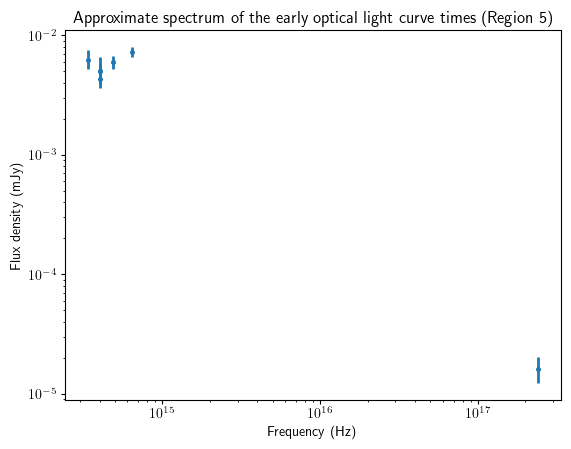

In [116]:
# From 1.75 days to 2.9:
maskg5 = (gTime.to_value(u.d) >= 1.75) & (gTime.to_value(u.d) <= 2.9)
maskr5 = (rTime.to_value(u.d) >= 1.75) & (rTime.to_value(u.d) <= 2.9)
maski5 = (iTime.to_value(u.d) >= 1.75) & (iTime.to_value(u.d) <= 2.9)
maskz5 = (zTime.to_value(u.d) >= 1.75) & (zTime.to_value(u.d) <= 2.9)

#Cutting the arrays:
gFlux5=gFlux[maskg5]
gFlux_e5=gFlux_e[maskg5]
gFlux_E5=gFlux_E[maskg5]
gFreq5=gFreq*np.ones(len(gFlux5))

rFlux5=rFlux[maskr5]
rFlux_e5=rFlux_e[maskr5]
rFlux_E5=rFlux_E[maskr5]
rFreq5=rFreq*np.ones(len(rFlux5))

iFlux5=iFlux[maski5]
iFlux_e5=iFlux_e[maski5]
iFlux_E5=iFlux_E[maski5]
iFreq5=iFreq*np.ones(len(iFlux5))

zFlux5=zFlux[maskz5]
zFlux_e5=zFlux_e[maskz5]
zFlux_E5=zFlux_E[maskz5]
zFreq5=zFreq*np.ones(len(zFlux5))



#In this order:  X-ray, g, r, i ,z
Flux5=np.append((Xray['Flux-Density(micro-Jankys)'][4].data*u.uJy).to(u.mJy),gFlux5)
Flux5=np.append(Flux5,rFlux5)
Flux5=np.append(Flux5,iFlux5)
Flux5=np.append(Flux5,zFlux5)

Flux5_e=np.append((Xray['Flux-Density_e(micro-Jankys)'][4].data*u.uJy).to(u.mJy),gFlux_e5)
Flux5_e=np.append(Flux5_e,rFlux_e5)
Flux5_e=np.append(Flux5_e,iFlux_e5)
Flux5_e=np.append(Flux5_e,zFlux_e5)

Flux5_E=np.append((Xray['Flux-Density_E(micro-Jankys)'][4].data*u.uJy).to(u.mJy),gFlux_E5)
Flux5_E=np.append(Flux5_E,rFlux_E5)
Flux5_E=np.append(Flux5_E,iFlux_E5)
Flux5_E=np.append(Flux5_E,zFlux_E5)

Freq5=np.append(XrayFreq.data[1],gFreq5)
Freq5=np.append(Freq5,rFreq5)
Freq5=np.append(Freq5,iFreq5)
Freq5=np.append(Freq5,zFreq5)

#And plotting the result:
plt.figure()
plt.errorbar(x=Freq5, y=Flux5, yerr=np.vstack([Flux5_e,Flux5_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 5)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

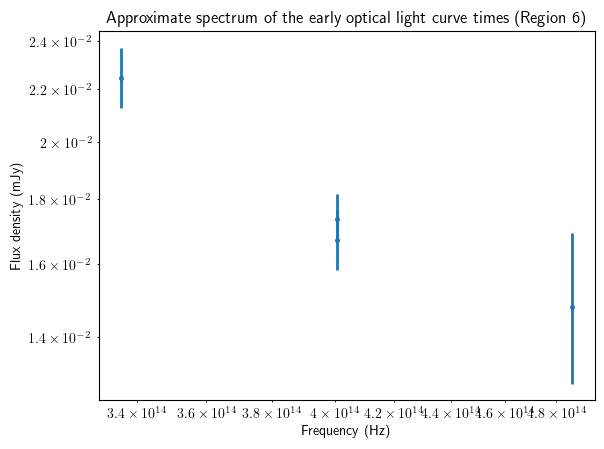

In [117]:
# From 2.9 days to 3.6:
maskg6 = (gTime.to_value(u.d) >= 2.9) & (gTime.to_value(u.d) <= 3.6)
maskr6 = (rTime.to_value(u.d) >= 2.9) & (rTime.to_value(u.d) <= 3.6)
maski6 = (iTime.to_value(u.d) >= 2.9) & (iTime.to_value(u.d) <= 3.6)
maskz6 = (zTime.to_value(u.d) >= 2.9) & (zTime.to_value(u.d) <= 3.6)

#Cutting the arrays:
gFlux6=gFlux[maskg6]
gFlux_e6=gFlux_e[maskg6]
gFlux_E6=gFlux_E[maskg6]
gFreq6=gFreq*np.ones(len(gFlux6))

rFlux6=rFlux[maskr6]
rFlux_e6=rFlux_e[maskr6]
rFlux_E6=rFlux_E[maskr6]
rFreq6=rFreq*np.ones(len(rFlux6))

iFlux6=iFlux[maski6]
iFlux_e6=iFlux_e[maski6]
iFlux_E6=iFlux_E[maski6]
iFreq6=iFreq*np.ones(len(iFlux6))

zFlux6=zFlux[maskz6]
zFlux_e6=zFlux_e[maskz6]
zFlux_E6=zFlux_E[maskz6]
zFreq6=zFreq*np.ones(len(zFlux6))



#In this order: g, r, i ,z
Flux6=np.append(gFlux6,rFlux6)
Flux6=np.append(Flux6,iFlux6)
Flux6=np.append(Flux6,zFlux6)

Flux6_e=np.append(gFlux_e6,rFlux_e6)
Flux6_e=np.append(Flux6_e,iFlux_e6)
Flux6_e=np.append(Flux6_e,zFlux_e6)

Flux6_E=np.append(gFlux_E6,rFlux_E6)
Flux6_E=np.append(Flux6_E,iFlux_E6)
Flux6_E=np.append(Flux6_E,zFlux_E6)

Freq6=np.append(gFreq6,rFreq6)
Freq6=np.append(Freq6,iFreq6)
Freq6=np.append(Freq6,zFreq6)

#And plotting the result:
plt.figure()
plt.errorbar(x=Freq6, y=Flux6, yerr=np.vstack([Flux6_e,Flux6_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 6)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

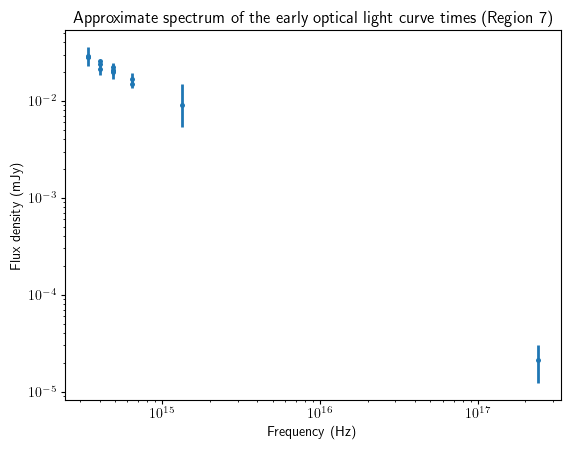

In [118]:
# From 3.6 days to 4.3:
maskg7 = (gTime.to_value(u.d) >= 3.6) & (gTime.to_value(u.d) <= 4.3)
maskr7 = (rTime.to_value(u.d) >= 3.6) & (rTime.to_value(u.d) <= 4.3)
maski7 = (iTime.to_value(u.d) >= 3.6) & (iTime.to_value(u.d) <= 4.3)
maskz7 = (zTime.to_value(u.d) >= 3.6) & (zTime.to_value(u.d) <= 4.3)

#Cutting the arrays:
gFlux7=gFlux[maskg7]
gFlux_e7=gFlux_e[maskg7]
gFlux_E7=gFlux_E[maskg7]
gFreq7=gFreq*np.ones(len(gFlux7))

rFlux7=rFlux[maskr7]
rFlux_e7=rFlux_e[maskr7]
rFlux_E7=rFlux_E[maskr7]
rFreq7=rFreq*np.ones(len(rFlux7))

iFlux7=iFlux[maski7]
iFlux_e7=iFlux_e[maski7]
iFlux_E7=iFlux_E[maski7]
iFreq7=iFreq*np.ones(len(iFlux7))

zFlux7=zFlux[maskz7]
zFlux_e7=zFlux_e[maskz7]
zFlux_E7=zFlux_E[maskz7]
zFreq7=zFreq*np.ones(len(zFlux7))

IRmask7=(IRtime.to_value(u.d) > 3.6) & (IRtime.to_value(u.d) <= 4.3)
IRfreq7=IRfreq[IRmask7]
IRFlux7=IRFlux[IRmask7]
IRFlux_e7=IRFlux_e[IRmask7]
IRFlux_E7=IRFlux_E[IRmask7]

#In this order: IRUV, Xray g, r, i ,z
Flux7=np.append(IRFlux7,(Xray['Flux-Density(micro-Jankys)'][5].data*u.uJy).to(u.mJy))
Flux7=np.append(Flux7,gFlux7)
Flux7=np.append(Flux7,rFlux7)
Flux7=np.append(Flux7,iFlux7)
Flux7=np.append(Flux7,zFlux7)

Flux7_e=np.append(IRFlux_e7,(Xray['Flux-Density_e(micro-Jankys)'][5].data*u.uJy).to(u.mJy))
Flux7_e=np.append(Flux7_e,gFlux_e7)
Flux7_e=np.append(Flux7_e,rFlux_e7)
Flux7_e=np.append(Flux7_e,iFlux_e7)
Flux7_e=np.append(Flux7_e,zFlux_e7)

Flux7_E=np.append(IRFlux_E7,(Xray['Flux-Density_E(micro-Jankys)'][5].data*u.uJy).to(u.mJy))
Flux7_E=np.append(Flux7_E,gFlux_E7)
Flux7_E=np.append(Flux7_E,rFlux_E7)
Flux7_E=np.append(Flux7_E,iFlux_E7)
Flux7_E=np.append(Flux7_E,zFlux_E7)

Freq7=np.append(IRfreq7,XrayFreq.data[1])
Freq7=np.append(Freq7,gFreq7)
Freq7=np.append(Freq7,rFreq7)
Freq7=np.append(Freq7,iFreq7)
Freq7=np.append(Freq7,zFreq7)

#And plotting the result:
plt.figure()
plt.errorbar(x=Freq7, y=Flux7, yerr=np.vstack([Flux7_e,Flux7_E]),  fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 7)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

[ 6.46 30.48 62.32] d


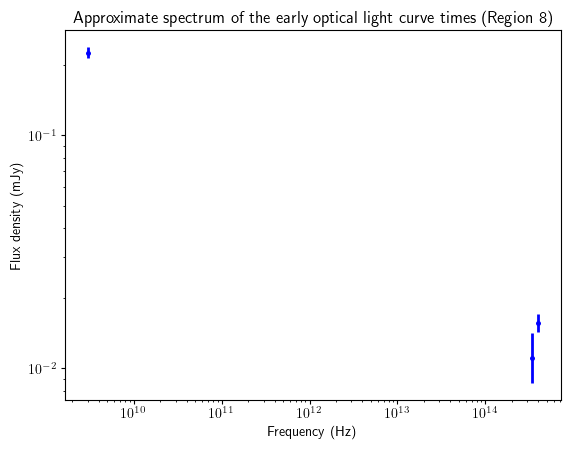

In [119]:
#Finally, also including one radio point:
#Region 8: from 6 days to 7
print((Radio['Since-Trigger-Observed(s)'][GHz3Dat]*u.s).to(u.d))

# From 6 days to 7:
maskg8 = (gTime.to_value(u.d) >= 6) & (gTime.to_value(u.d) <= 7)
maskr8 = (rTime.to_value(u.d) >= 6) & (rTime.to_value(u.d) <= 7)
maski8 = (iTime.to_value(u.d) >= 6) & (iTime.to_value(u.d) <= 7)
maskz8 = (zTime.to_value(u.d) >= 6) & (zTime.to_value(u.d) <= 7)

#Cutting the arrays:
gFlux8=gFlux[maskg8]
gFlux_e8=gFlux_e[maskg8]
gFlux_E8=gFlux_E[maskg8]
gFreq8=gFreq*np.ones(len(gFlux8))

rFlux8=rFlux[maskr8]
rFlux_e8=rFlux_e[maskr8]
rFlux_E8=rFlux_E[maskr8]
rFreq8=rFreq*np.ones(len(rFlux8))

iFlux8=iFlux[maski8]
iFlux_e8=iFlux_e[maski8]
iFlux_E8=iFlux_E[maski8]
iFreq8=iFreq*np.ones(len(iFlux8))

zFlux8=zFlux[maskz8]
zFlux_e8=zFlux_e[maskz8]
zFlux_E8=zFlux_E[maskz8]
zFreq8=zFreq*np.ones(len(zFlux8))


#In this order: Radio, g, r, i ,z
Flux8=np.append((Radio['Flux-Density-(micro-Jankys)'][GHz3Dat][0]*u.uJy).to(u.mJy),gFlux8)
Flux8=np.append(Flux8,rFlux8)
Flux8=np.append(Flux8,iFlux8)
Flux8=np.append(Flux8,zFlux8)

Flux8_e=np.append((Radio['Flux-Density-error-(micro-Jankys)'][GHz3Dat][0]*u.uJy).to(u.mJy),gFlux_e8)
Flux8_e=np.append(Flux8_e,rFlux_e8)
Flux8_e=np.append(Flux8_e,iFlux_e8)
Flux8_e=np.append(Flux8_e,zFlux_e8)


Flux8_E=np.append((Radio['Flux-Density-error-(micro-Jankys)'][GHz3Dat][0]*u.uJy).to(u.mJy),gFlux_E8)
Flux8_E=np.append(Flux8_E,rFlux_E8)
Flux8_E=np.append(Flux8_E,iFlux_E8)
Flux8_E=np.append(Flux8_E,zFlux_E8)

Freq8=np.append(3*1e9,gFreq8)
Freq8=np.append(Freq8,rFreq8)
Freq8=np.append(Freq8,iFreq8)
Freq8=np.append(Freq8,zFreq8)


#And plotting the result:
plt.figure()
plt.errorbar(x=Freq8, y=Flux8, yerr=np.vstack([Flux8_e,Flux8_E]),  color='blue',fmt='o', capsize=5, elinewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Approximate spectrum of the early optical light curve times (Region 8)')
plt.ylabel('Flux density (mJy)')
plt.xlabel('Frequency (Hz)')
plt.show()

## Fitting the power law to these regions:


In [120]:
# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:
LogFlux4Fit=np.log10(Flux4.value)
LogFlux4Fit_e=Flux4_e.value / (Flux4.value * np.log(10))
LogFlux4Fit_E=Flux4_E.value / (Flux4.value * np.log(10))

# So, fitting:
#For the power law:
poptPL4, pcovPL4 = curve_fit(logPLSED, Freq4, LogFlux4Fit, sigma=np.maximum(LogFlux4Fit_e,LogFlux4Fit_E))

a_fit4, beta_fit4 = poptPL4
perrPL4 = np.sqrt(np.diag(pcovPL4))
print('Best fitting a parameter (Region 4): ', a_fit4, 'pm', perrPL4[0]) 
print('Best fitting beta parameter (Region 4): ', beta_fit4, 'pm', perrPL4[1])


# model residuals
y_modelPL4 = logPLSED(Freq4, a_fit4, beta_fit4)
residualsPL4 =  LogFlux4Fit - y_modelPL4

# using symmetric sigma (maximum of lower/upper)
sigma_symPL4 = np.maximum(LogFlux4Fit_e, LogFlux4Fit_E)

chi2PL4 = np.sum((residualsPL4 / sigma_symPL4)**2)
dofPL4 = len(LogFlux4Fit) - len(poptPL4)  # degrees of freedom: data points - parameters
chi2_redPL4 = chi2PL4 / dofPL4

print("chi2 (Region 4) =", chi2PL4)
print("reduced chi2 (Region 4) =", chi2_redPL4)



# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:
LogFlux5Fit=np.log10(Flux5.value)
LogFlux5Fit_e=Flux5_e.value / (Flux5.value * np.log(10))
LogFlux5Fit_E=Flux5_E.value / (Flux5.value * np.log(10))

# So, fitting:
#For the power law:
poptPL5, pcovPL5 = curve_fit(logPLSED, Freq5, LogFlux5Fit, sigma=np.maximum(LogFlux5Fit_e,LogFlux5Fit_E))

a_fit5, beta_fit5 = poptPL5
perrPL5 = np.sqrt(np.diag(pcovPL5))
print('Best fitting a parameter (Region 5): ', a_fit5, 'pm', perrPL5[0]) 
print('Best fitting beta parameter (Region 5): ', beta_fit5, 'pm', perrPL5[1])


# model residuals
y_modelPL5 = logPLSED(Freq5, a_fit5, beta_fit5)
residualsPL5 =  LogFlux5Fit - y_modelPL5

# using symmetric sigma (maximum of lower/upper)
sigma_symPL5 = np.maximum(LogFlux5Fit_e, LogFlux5Fit_E)

chi2PL5 = np.sum((residualsPL5 / sigma_symPL5)**2)
dofPL5 = len(LogFlux5Fit) - len(poptPL5)  # degrees of freedom: data points - parameters
chi2_redPL5 = chi2PL5 / dofPL5

print("chi2 (Region 5) =", chi2PL5)
print("reduced chi2 (Region 5) =", chi2_redPL5)




# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:
LogFlux6Fit=np.log10(Flux6.value)
LogFlux6Fit_e=Flux6_e.value / (Flux6.value * np.log(10))
LogFlux6Fit_E=Flux6_E.value / (Flux6.value * np.log(10))

# So, fitting:
#For the power law:
poptPL6, pcovPL6 = curve_fit(logPLSED, Freq6, LogFlux6Fit, sigma=np.maximum(LogFlux6Fit_e,LogFlux6Fit_E))

a_fit6, beta_fit6 = poptPL6
perrPL6 = np.sqrt(np.diag(pcovPL6))
print('Best fitting a parameter (Region 6): ', a_fit6, 'pm', perrPL6[0]) 
print('Best fitting beta parameter (Region 6): ', beta_fit6, 'pm', perrPL6[1])


# model residuals
y_modelPL6 = logPLSED(Freq6, a_fit6, beta_fit6)
residualsPL6 =  LogFlux6Fit - y_modelPL6

# using symmetric sigma (maximum of lower/upper)
sigma_symPL6 = np.maximum(LogFlux6Fit_e, LogFlux6Fit_E)

chi2PL6 = np.sum((residualsPL6 / sigma_symPL6)**2)
dofPL6 = len(LogFlux6Fit) - len(poptPL6)  # degrees of freedom: data points - parameters
chi2_redPL6 = chi2PL6 / dofPL6

print("chi2 (Region 6) =", chi2PL6)
print("reduced chi2 (Region 6) =", chi2_redPL6)




# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:
LogFlux7Fit=np.log10(Flux7.value)
LogFlux7Fit_e=Flux7_e.value / (Flux7.value * np.log(10))
LogFlux7Fit_E=Flux7_E.value / (Flux7.value * np.log(10))

# So, fitting:
#For the power law:
poptPL7, pcovPL7 = curve_fit(logPLSED, Freq7, LogFlux7Fit, sigma=np.maximum(LogFlux7Fit_e,LogFlux7Fit_E))

a_fit7, beta_fit7 = poptPL7
perrPL7 = np.sqrt(np.diag(pcovPL7))
print('Best fitting a parameter (Region 7): ', a_fit7, 'pm', perrPL7[0]) 
print('Best fitting beta parameter (Region 7): ', beta_fit7, 'pm', perrPL7[1])


# model residuals
y_modelPL7 = logPLSED(Freq7, a_fit7, beta_fit7)
residualsPL7 =  LogFlux7Fit - y_modelPL7

# using symmetric sigma (maximum of lower/upper)
sigma_symPL7 = np.maximum(LogFlux7Fit_e, LogFlux7Fit_E)

chi2PL7 = np.sum((residualsPL7 / sigma_symPL7)**2)
dofPL7 = len(LogFlux7Fit) - len(poptPL7)  # degrees of freedom: data points - parameters
chi2_redPL7 = chi2PL7 / dofPL7

print("chi2 (Region 7) =", chi2PL7)
print("reduced chi2 (Region 7) =", chi2_redPL7)




# Now, fluxes must be in erg/s/Angstrom/cm^2 for the transient and fitting, so:
LogFlux8Fit=np.log10(Flux8.value)
LogFlux8Fit_e=Flux8_e.value / (Flux8.value * np.log(10))
LogFlux8Fit_E=Flux8_E.value / (Flux8.value * np.log(10))

# So, fitting:
#For the power law:
poptPL8, pcovPL8 = curve_fit(logPLSED, Freq8, LogFlux8Fit, sigma=np.maximum(LogFlux8Fit_e,LogFlux8Fit_E))

a_fit8, beta_fit8 = poptPL8
perrPL8 = np.sqrt(np.diag(pcovPL8))
print('Best fitting a parameter (Region 8): ', a_fit8, 'pm', perrPL8[0]) 
print('Best fitting beta parameter (Region 8): ', beta_fit8, 'pm', perrPL8[1])



# model residuals
y_modelPL8 = logPLSED(Freq8, a_fit8, beta_fit8)
residualsPL8 =  LogFlux8Fit - y_modelPL8

# using symmetric sigma (maximum of lower/upper)
sigma_symPL8 = np.maximum(LogFlux8Fit_e, LogFlux8Fit_E)

chi2PL8 = np.sum((residualsPL8 / sigma_symPL8)**2)
dofPL8 = len(LogFlux8Fit) - len(poptPL8)  # degrees of freedom: data points - parameters
chi2_redPL8 = chi2PL8 / dofPL8

print("chi2 (Region 8) =", chi2PL8)
print("reduced chi2 (Region 8) =", chi2_redPL8)

Best fitting a parameter (Region 4):  4.213774012342068 pm 7.714699188942072
Best fitting beta parameter (Region 4):  -0.4497862801435311 pm 0.5254557327017405
chi2 (Region 4) = 2.716931329260792
reduced chi2 (Region 4) = 0.9056437764202641
Best fitting a parameter (Region 5):  11.203511683980482 pm 1.631768282309021
Best fitting beta parameter (Region 5):  -0.914675857281546 pm 0.10985559449107793
chi2 (Region 5) = 34.67641730934747
reduced chi2 (Region 5) = 6.935283461869494
Best fitting a parameter (Region 6):  18.194872091336336 pm 3.3609182234993997
Best fitting beta parameter (Region 6):  -1.3665763028046964 pm 0.23043788042433483
chi2 (Region 6) = 1.0416143943511804
reduced chi2 (Region 6) = 0.5208071971755902
Best fitting a parameter (Region 7):  12.744350562749766 pm 0.629801902827098
Best fitting beta parameter (Region 7):  -0.9821415565256199 pm 0.043043018321545466
chi2 (Region 7) = 15.361026574952268
reduced chi2 (Region 7) = 1.280085547912689
Best fitting a parameter (Reg

Best fitting a parameter for the remainders of Region 1:  5.6441551370210306 pm 1.0992366114707444
Best fitting beta parameter for the remainders of Region 1:  -0.5219869334282523 pm 0.07505916743031038
Best fitting a parameter for the remainders of Region 2:  3.9494627318774964 pm 5.750649290891224
Best fitting beta parameter for the remainders of Region 2:  -0.4149183814436325 pm 0.3913113217194903
Best fitting a parameter for the remainders of Region 3:  50.39102523936831 pm inf
Best fitting beta parameter for the remainders of Region 3:  -3.591628673546776 pm inf
Best fitting a parameter for the remainders of Region 4:  8.814782047140925 pm 8.929805164959854
Best fitting beta parameter for the remainders of Region 4:  -0.7944655462584455 pm 0.6076416250324798


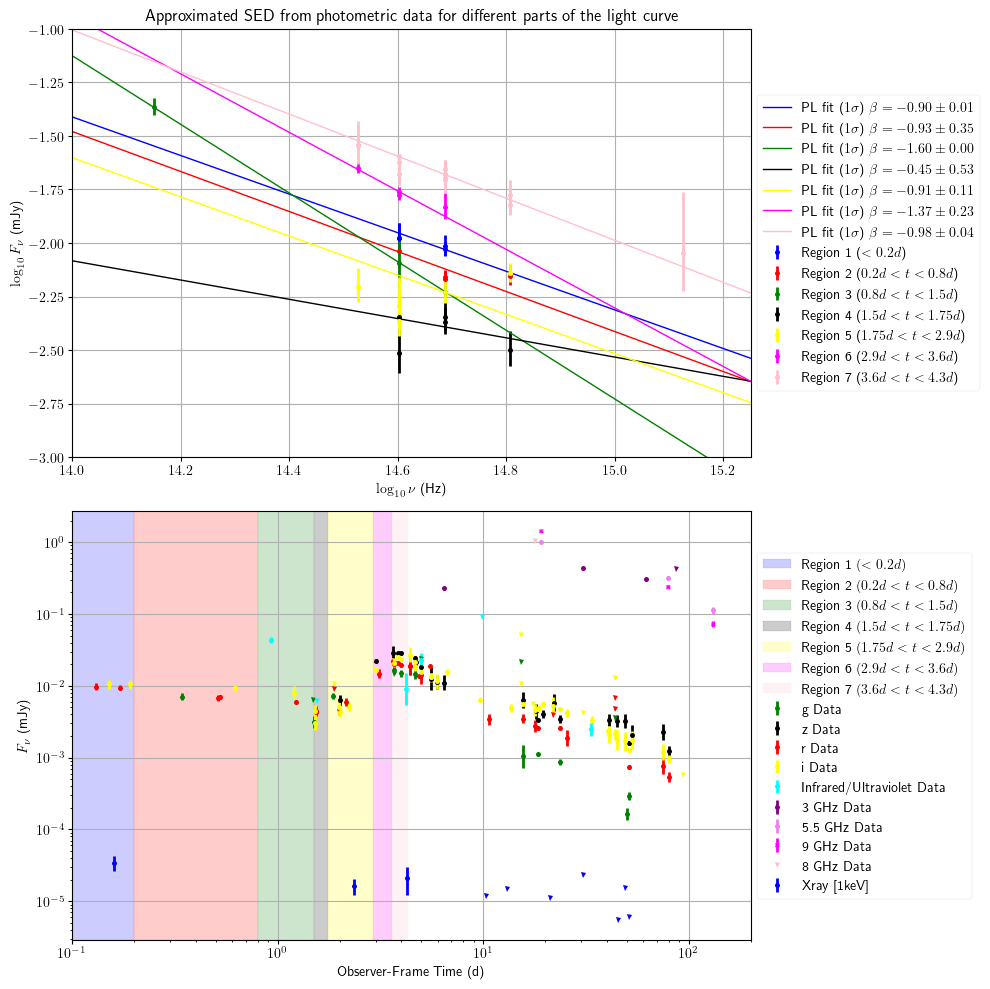

It is not advisable to include the radio point in the figure because, even if radio and optical data is explained by synchrotron emission,  over a range of five orders of magnitude there are likely to be break frequencies that alter the spectral trend characteristic of the nature of this emission, making this result the least reliable one.


In [124]:
#Plotting everything:

IRUVDet=IRUV['Upper Limits Nature']=='No'

#Also, for the non-afterglow component at the early optical part (<1.75days and only in optical yet, no X-ray or Radio)
#And fitting them afterwords:
#This is, in the regions 1, 2, 3 and 4(From the notebook of OpticalPeakFitResults):
rRest1=np.array([0.00964036, 0.00936462])
iRest1=np.array([1.05175326e-02, 1.05048799e-02])
FluxRest1=np.append(rRest1,iRest1)

#Region 2:
gRest2=np.array([0.0069018])
rRest2=np.array([0.00648244, 0.00660985])
iRest2=np.array([8.64877299e-03])
FluxRest2=np.append(gRest2,rRest2)
FluxRest2=np.append(FluxRest2,iRest2)


#Region 3:
rRest3=np.array([0.00437702])
iRest3=np.array([8.76941823e-03])
FluxRest3=np.append(rRest3,iRest3)

#Region 4:
gRest4=np.array([0.00100931])
rRest4=np.array([0.00171774, 0.00149256])
iRest4=np.array([1.39772103e-03])
FluxRest4=np.append(gRest4,rRest4)
FluxRest4=np.append(FluxRest4,iRest4)

#In log10:
LogFluxRest1=np.log10(FluxRest1)
LogFluxRest2=np.log10(FluxRest2)
LogFluxRest3=np.log10(FluxRest3)
LogFluxRest4=np.log10(FluxRest4)

Freqplot=np.append(Freq1,Freq2)
Freqplot=np.append(Freqplot, Freq3)
Freqplot=np.append(Freqplot, Freq4)
Freqplot=np.append(Freqplot, Freq5)
Freqplot=np.append(Freqplot, Freq6)
Freqplot=np.append(Freqplot, Freq7)
Freqplot=np.append(Freqplot, Freq8)

#Fitting them with a PL
poptPLREST1, pcovPLREST1 = curve_fit(logPLSED, Freq1[1:], LogFluxRest1)

a_fitREST1, beta_fitREST1 = poptPLREST1
perrPLREST1 = np.sqrt(np.diag(pcovPLREST1))
print('Best fitting a parameter for the remainders of Region 1: ', a_fitREST1, 'pm', perrPLREST1[0]) 
print('Best fitting beta parameter for the remainders of Region 1: ', beta_fitREST1, 'pm', perrPLREST1[1])


poptPLREST2, pcovPLREST2 = curve_fit(logPLSED, Freq2, LogFluxRest2)

a_fitREST2, beta_fitREST2 = poptPLREST2
perrPLREST2 = np.sqrt(np.diag(pcovPLREST2))
print('Best fitting a parameter for the remainders of Region 2: ', a_fitREST2, 'pm', perrPLREST2[0]) 
print('Best fitting beta parameter for the remainders of Region 2: ', beta_fitREST2, 'pm', perrPLREST2[1])



poptPLREST3, pcovPLREST3 = curve_fit(logPLSED, Freq3[1:], LogFluxRest3)

a_fitREST3, beta_fitREST3 = poptPLREST3
perrPLREST3 = np.sqrt(np.diag(pcovPLREST3))
print('Best fitting a parameter for the remainders of Region 3: ', a_fitREST3, 'pm', perrPLREST3[0]) 
print('Best fitting beta parameter for the remainders of Region 3: ', beta_fitREST3, 'pm', perrPLREST3[1])



poptPLREST4, pcovPLREST4 = curve_fit(logPLSED, Freq4[0:-1], LogFluxRest4)

a_fitREST4, beta_fitREST4 = poptPLREST4
perrPLREST4 = np.sqrt(np.diag(pcovPLREST4))
print('Best fitting a parameter for the remainders of Region 4: ', a_fitREST4, 'pm', perrPLREST4[0]) 
print('Best fitting beta parameter for the remainders of Region 4: ', beta_fitREST4, 'pm', perrPLREST4[1])




xplot=np.linspace(np.log10(Freqplot.min()), np.log10(Freqplot.max()), 300)
yplot1=logPLSED(10**(xplot), *poptPL)
onesigmalow1=logPLSED(10**(xplot), *(poptPL-perrPL))
onesigmaupper1=logPLSED(10**(xplot), *(poptPL+perrPL))

yplot2=logPLSED(10**(xplot), *popt2)
onesigmalow2=logPLSED(10**(xplot), *(popt2-perr2))
onesigmaupper2=logPLSED(10**(xplot), *(popt2+perr2))

yplot3=logPLSED(10**(xplot), *popt3)
onesigmalow3=logPLSED(10**(xplot), *(popt3-perr3))
onesigmaupper3=logPLSED(10**(xplot), *(popt3+perr3))

yplot4=logPLSED(10**(xplot), *poptPL4)
onesigmalow4=logPLSED(10**(xplot), *(poptPL4-perrPL4))
onesigmaupper4=logPLSED(10**(xplot), *(poptPL4+perrPL4))


yplot5=logPLSED(10**(xplot), *poptPL5)
onesigmalow5=logPLSED(10**(xplot), *(poptPL5-perrPL5))
onesigmaupper5=logPLSED(10**(xplot), *(poptPL5+perrPL5))


yplot6=logPLSED(10**(xplot), *poptPL6)
onesigmalow6=logPLSED(10**(xplot), *(poptPL6-perrPL6))
onesigmaupper6=logPLSED(10**(xplot), *(poptPL6+perrPL6))


yplot7=logPLSED(10**(xplot), *poptPL7)
onesigmalow7=logPLSED(10**(xplot), *(poptPL7-perrPL7))
onesigmaupper7=logPLSED(10**(xplot), *(poptPL7+perrPL7))


yplot8=logPLSED(10**(xplot), *poptPL8)
onesigmalow8=logPLSED(10**(xplot), *(poptPL8-perrPL8))
onesigmaupper8=logPLSED(10**(xplot), *(poptPL8+perrPL8))

yplotREST1=logPLSED(10**(xplot), *poptPLREST1)
onesigmalowREST1=logPLSED(10**(xplot), *(poptPLREST1-perrPLREST1))
onesigmaupperREST1=logPLSED(10**(xplot), *(poptPLREST1+perrPLREST1))

yplotREST2=logPLSED(10**(xplot), *poptPLREST2)
onesigmalowREST2=logPLSED(10**(xplot), *(poptPLREST2-perrPLREST2))
onesigmaupperREST2=logPLSED(10**(xplot), *(poptPLREST2+perrPLREST2))

yplotREST3=logPLSED(10**(xplot), *poptPLREST3)
onesigmalowREST3=logPLSED(10**(xplot), *(poptPLREST3-perrPLREST3))
onesigmaupperREST3=logPLSED(10**(xplot), *(poptPLREST3+perrPLREST3))

yplotREST4=logPLSED(10**(xplot), *poptPLREST4)
onesigmalowREST4=logPLSED(10**(xplot), *(poptPLREST4-perrPLREST4))
onesigmaupperREST4=logPLSED(10**(xplot), *(poptPLREST4+perrPLREST4))


fig2, (ax1,ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.errorbar(x=np.log10(Freq1), y=LogFlux1Fit, yerr=np.vstack([LogFlux1Fit_e,LogFlux1Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'blue', label='Region 1 ($<0.2d$)')
ax1.errorbar(x=np.log10(Freq2), y=LogFlux2Fit, yerr=np.vstack([LogFlux2Fit_e,LogFlux2Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'red', label='Region 2 ($0.2d<t<0.8d$)')
ax1.errorbar(x=np.log10(Freq3), y=LogFlux3Fit, yerr=np.vstack([LogFlux3Fit_e,LogFlux3Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'green', label='Region 3 ($0.8d<t<1.5d$)')
ax1.errorbar(x=np.log10(Freq4), y=LogFlux4Fit, yerr=np.vstack([LogFlux4Fit_e,LogFlux4Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'black', label='Region 4 ($1.5d<t<1.75d$)')
ax1.errorbar(x=np.log10(Freq5), y=LogFlux5Fit, yerr=np.vstack([LogFlux5Fit_e,LogFlux5Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'yellow', label='Region 5 ($1.75d<t<2.9d$)')
ax1.errorbar(x=np.log10(Freq6), y=LogFlux6Fit, yerr=np.vstack([LogFlux6Fit_e,LogFlux6Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'magenta', label='Region 6 ($2.9d<t<3.6d$)')
ax1.errorbar(x=np.log10(Freq7), y=LogFlux7Fit, yerr=np.vstack([LogFlux7Fit_e,LogFlux7Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'pink', label='Region 7 ($3.6d<t<4.3d$)')
#ax1.errorbar(x=np.log10(Freq8), y=LogFlux8Fit, yerr=np.vstack([LogFlux8Fit_e,LogFlux8Fit_E]),  fmt='o', capsize=5, elinewidth=2, color= 'orange', label='Region 8 ($6d<t<7d$)')

ax1.plot(xplot, yplot1, color="blue", label=rf"PL fit ($1\sigma$) $\beta={beta_fit:.2f} \pm {perrPL[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow1, onesigmaupper1, alpha= 0.3,color="blue")
ax1.plot(xplot, yplot2, color="red", label=rf"PL fit ($1\sigma$) $\beta={beta_fit2:.2f} \pm {perr2[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow2, onesigmaupper2, alpha= 0.3,color="red")
ax1.plot(xplot, yplot3, color="green", label=rf"PL fit ($1\sigma$) $\beta={beta_fit3:.2f} \pm {perr3[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow3, onesigmaupper3, alpha= 0.3,color="green")
ax1.plot(xplot, yplot4, color="black", label=rf"PL fit ($1\sigma$) $\beta={beta_fit4:.2f} \pm {perrPL4[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow4, onesigmaupper4, alpha= 0.3,color="yellow")
ax1.plot(xplot, yplot5, color="yellow", label=rf"PL fit ($1\sigma$) $\beta={beta_fit5:.2f} \pm {perrPL5[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow5, onesigmaupper5, alpha= 0.3,color="magenta")
ax1.plot(xplot, yplot6, color="magenta", label=rf"PL fit ($1\sigma$) $\beta={beta_fit6:.2f} \pm {perrPL6[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow6, onesigmaupper6, alpha= 0.3,color="yellow")
ax1.plot(xplot, yplot7, color="pink", label=rf"PL fit ($1\sigma$) $\beta={beta_fit7:.2f} \pm {perrPL7[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow7, onesigmaupper7, alpha= 0.3,color="pink")
#ax1.plot(xplot, yplot8, color="orange", label=rf"PL fit ($1\sigma$) $\beta={beta_fit8:.2f} \pm {perrPL8[1]:.2f}$")
#ax1.fill_between(xplot, onesigmalow8, onesigmaupper8, alpha= 0.3,color="orange")

# ax1.plot(xplot, yplotREST1, color="cyan", label=rf"PL fit Remainders (R1) $\beta={beta_fitREST1:.2f} \pm {perrPLREST1[1]:.2f}$")
# ax1.plot(xplot, yplotREST2, color="darkred", label=rf"PL fit Remainders (R2) $\beta={beta_fitREST2:.2f} \pm {perrPLREST2[1]:.2f}$")
# ax1.plot(xplot, yplotREST3, color="darkgreen", label=rf"PL fit Remainders (R3) $\beta={beta_fitREST3:.2f} \pm {perrPLREST3[1]:.2f}$")
# ax1.plot(xplot, yplotREST4, color="violet", label=rf"PL fit Remainders (R4) $\beta={beta_fitREST4:.2f} \pm {perrPLREST4[1]:.2f}$")


# ax1.scatter(x=np.log10(Freq1[1:]), y=LogFluxRest1, marker='s', color='cyan', label='Region 1 data-afterglow model')
# ax1.scatter(x=np.log10(Freq2), y=LogFluxRest2, marker='s', color='darkred', label='Region 2 data-afterglow model')
# ax1.scatter(x=np.log10(Freq3[1:]), y=LogFluxRest3, marker='s', color='darkgreen', label='Region 3 data-afterglow model')
# ax1.scatter(x=np.log10(Freq4[0:-1]), y=LogFluxRest4, marker='s', color='violet', label='Region 4 data-afterglow model')


ax1.set_title('Approximated SED from photometric data for different parts of the light curve')
ax1.set_ylabel(rf"$\log_{{10}} F_{{\nu}}$ (mJy)")
ax1.set_xlabel(rf"$\log_{{10}} \nu$ (Hz)")
ax1.set_ylim(-3, -1)
ax1.set_xlim(14, 15.25)
ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax1.grid()





#Data points:
#g band
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[gind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind], yerr=np.vstack([1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[gind], 1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[gind]]), fmt='o', capsize=5, elinewidth=2 ,label= 'g Data', color='green')
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[gUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[gUBind], fmt='v', capsize=5, elinewidth=2, color='green')
#z band
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[zind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind], yerr=np.vstack([1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[zind], 1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[zind]]), fmt='o', capsize=5, elinewidth=2 ,label= 'z Data', color='black')
#r band
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[rind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind], yerr=np.vstack([1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[rind], 1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[rind]]), fmt='o', capsize=5, elinewidth=2 ,label= 'r Data', color='red')
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[rUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[rUBind], fmt='v', capsize=5, elinewidth=2, color='red')
#i band
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[iind]*stod,  1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind], yerr=np.vstack([1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[iind], 1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[iind]]), fmt='o', capsize=5, elinewidth=2 ,label= 'i Data', color='yellow')
ax2.errorbar(Optical['Since-Trigger-Observed(s)'].value[iUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[iUBind], fmt='v', capsize=5, elinewidth=2, color='yellow')

#IRUV data:
ax2.errorbar(IRUV['Since-Trigger-Observed (s)'].value[IRUVDet]*stod,  1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet], yerr=np.vstack([1e-3*IRUV['Flux-Density_e(micro-Jankys)'].value[IRUVDet], 1e-3*IRUV['Flux-Density_E(micro-Jankys)'].value[IRUVDet]]), fmt='o', capsize=5, elinewidth=2 ,label= 'Infrared/Ultraviolet Data', color='cyan')
ax2.errorbar(IRUV['Since-Trigger-Observed (s)'].value[~IRUVDet]*stod, 1e-3*IRUV['Flux-Density(micro-Jankys)'].value[~IRUVDet], fmt='v', capsize=5, elinewidth=2, color='cyan')

#Radio band
#3GHz
ax2.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz3Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3Dat], yerr=1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz3Dat], fmt='o', capsize=5, elinewidth=2 ,label= '3 GHz Data', color='purple')
ax2.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz3UB]*stod, 1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3UB], fmt='v', capsize=5, elinewidth=2, color='purple')
#5.5GHz
ax2.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz5Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz5Dat], yerr=1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz5Dat], fmt='o', capsize=5, elinewidth=2 ,label= '5.5 GHz Data', color='violet')

#9GHz
ax2.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz9Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz9Dat], yerr=1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz9Dat], fmt='X', capsize=5, elinewidth=2 ,label= '9 GHz Data', color='magenta')

#8GHz
ax2.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz8UB]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz8UB], fmt='v', capsize=5, elinewidth=2 ,label= '8 GHz Data', color='pink')

#Xrays
ax2.errorbar(Xray['Since-Trigger-Observed(s)'].value[XRAYDat]*stod,  1e-3*Xray['Flux-Density(micro-Jankys)'].value[XRAYDat], yerr=np.vstack([1e-3*Xray['Flux-Density_e(micro-Jankys)'].value[XRAYDat],1e-3*Xray['Flux-Density_E(micro-Jankys)'].value[XRAYDat]]), fmt='o', capsize=5, elinewidth=2 ,label= 'Xray [1keV]', color='blue')
ax2.errorbar(Xray['Since-Trigger-Observed(s)'].value[XRAYUB]*stod, 1e-3*Xray['Flux-Density(micro-Jankys)'].value[XRAYUB], fmt='v', capsize=5, elinewidth=2, color='blue')


#Different regions:
ax2.axvspan(0.1, 0.2, color="blue", alpha=0.2, label="Region 1 $(<0.2d)$")
ax2.axvspan(0.2, 0.8, color="red", alpha=0.2, label="Region 2 $(0.2d < t < 0.8d)$")
ax2.axvspan(0.8, 1.5, color="green", alpha=0.2, label="Region 3 $(0.8d < t < 1.5d)$")
ax2.axvspan(1.5, 1.75, color="black", alpha=0.2, label="Region 4 $(1.5d < t < 1.75d)$")
ax2.axvspan(1.75, 2.9, color="yellow", alpha=0.2, label="Region 5 $(1.75d < t < 2.9d)$")
ax2.axvspan(2.9, 3.6, color="magenta", alpha=0.2, label="Region 6 $(2.9d < t < 3.6d)$")
ax2.axvspan(3.6, 4.3, color="pink", alpha=0.2, label="Region 7 $(3.6d < t < 4.3d)$")
#ax2.axvspan(6, 7, color="orange", alpha=0.2, label="Region 8 $(6d < t < 7d)$")

ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylabel(rf"$F_{{\nu}}$ (mJy)")
ax2.set_xlabel('Observer-Frame Time (d)')
ax2.set_xlim(1e-1,2e2)
ax2.grid()

fig2.tight_layout()
plt.show()
plt.close(fig2)

print('It is not advisable to include the radio point in the figure because, even if radio and optical data is explained by synchrotron emission,  over a range of five orders of magnitude there are likely to be break frequencies that alter the spectral trend characteristic of the nature of this emission, making this result the least reliable one.')